# scPoli校正流程 Python版

把`原始基因表达h5ad`和`cell×10 scPoli h5ad`合并，按Seurat代码逻辑做epithelial subset、Normalize、UMAP过滤、scPoli聚类、local purity过滤、marker DotPlot和统计输出。

该文件的输出都在：/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_allhuman/work_0513_2

# import

In [2]:
import anndata
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
sc.settings.verbosity=2
sc.settings.seed=1234
np.random.seed(1234)

In [2]:
raw_h5ad="../../7_mapping_new_data/0521_no_Basophil/output_human/all_human_atlas_allgene_annot_counts.h5ad"##所有人类数据 原始counts + annot,现在这个文件中的cell_type_level1是ground truth
scpoli_h5ad="../../7_mapping_new_data/0521_no_Basophil/output_human/level1_human_atlas_nogene_umap.h5ad"### all human scpoli data without gene names, but with annotation
outdir="./output_human/"
counts_layer="rounded_corrected_counts"
original_celltype_col="cell_type_level1"##原始文件里的标签
os.makedirs(outdir,exist_ok=True)

In [3]:
#####读取文件 按 adata_scpoli 的细胞ID 对齐 adata_raw
adata_raw=sc.read_h5ad(raw_h5ad)
adata_scpoli=sc.read_h5ad(scpoli_h5ad)
print(adata_raw)
print(adata_raw.obs_names)
print(adata_scpoli)
print(adata_scpoli.obs_names)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1020052 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Index(['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1', 'AAACCCAAGGAGTCTG-1',
       'AAACCCACAACTCATG-1', 'AAACCCACAGCTCTGG-1', 'AAACCCAGTCAAGGCA-1',
       'AAACCCAGTCAATCTG-1', 'AAACCCAGTCACCCTT-1', 'AAACCCAGTGCATTAC-1',
       'AAACCCAGTGCGGCTT-1',
       ...
       'ATAACGCAGTACGCCC_H_plaque', 'CACATAGGTGTCTGAT_H_plaque',
       'CCATTCGAGTAGCCGA_H_plaque', 'GAATAAGAGAAAGTGG_H_plaque',
       'GACCAATCATGGTAGG_H_plaque', 'GACCTGGGTCT

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
###得到共同的细胞
adata_raw.obs_names=adata_raw.obs_names.astype(str)
adata_scpoli.obs_names=adata_scpoli.obs_names.astype(str)
##保留原始barcode
adata_raw.obs["barcode_for_match"]=adata_raw.obs_names
adata_scpoli.obs["barcode_for_match"]=adata_scpoli.obs_names.str[:-2]
##用 sample + barcode 构建唯一ID
adata_raw.obs["match_id"]=adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
adata_scpoli.obs["match_id"]=adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
##如果sample仍不唯一，就改成 dataset + sample + barcode
if adata_raw.obs["match_id"].duplicated().sum()>0 or adata_scpoli.obs["match_id"].duplicated().sum()>0:
    adata_raw.obs["match_id"]=adata_raw.obs["dataset"].astype(str)+"__"+adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
    adata_scpoli.obs["match_id"]=adata_scpoli.obs["dataset"].astype(str)+"__"+adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
print("raw duplicated match_id:",adata_raw.obs["match_id"].duplicated().sum())
print("scpoli duplicated match_id:",adata_scpoli.obs["match_id"].duplicated().sum())
if adata_raw.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_raw match_id仍有重复，不能安全匹配")
if adata_scpoli.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_scpoli match_id仍有重复，不能安全匹配")
adata_raw.obs_names=adata_raw.obs["match_id"].astype(str)
adata_scpoli.obs_names=adata_scpoli.obs["match_id"].astype(str)

##空值填充为query
if "atlas_key" not in adata_scpoli.obs:
    adata_scpoli.obs["atlas_key"]="query"
else:
    adata_scpoli.obs["atlas_key"]=adata_scpoli.obs["atlas_key"].astype("object")
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].isna(),"atlas_key"]="query"
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].astype(str).isin(["","nan","None","NA"]),"atlas_key"]="query"

print(adata_scpoli.obs["atlas_key"].value_counts(dropna=False))
##以 scpoli 为准，从 raw 中取相同细胞
scp_ids=adata_scpoli.obs_names
missing=scp_ids[~scp_ids.isin(adata_raw.obs_names)]
print("scpoli cells:",len(scp_ids))
print("missing in raw:",len(missing))
if len(missing)>0:
    print(missing[:50].tolist())
    raise ValueError("有 scpoli 细胞在 raw 中找不到")
adata=adata_raw[scp_ids,:].copy()
adata_com_scpoli=adata_scpoli.copy()
assert np.all(adata.obs_names==adata_com_scpoli.obs_names)
print("aligned adata:",adata)
print("aligned adata_com_scpoli:",adata_com_scpoli)

raw duplicated match_id: 0
scpoli duplicated match_id: 0
atlas_key
query    548208
ref      471480
Name: count, dtype: int64
scpoli cells: 1019688
missing in raw: 0
aligned adata: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
aligned adata_com_scpoli: AnnData object with n_obs × n_vars = 1019688 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_conta

In [5]:
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [6]:
adata.obs['atlas_key'].value_counts()

atlas_key
query    548208
ref      471480
Name: count, dtype: int64

In [7]:
adata_com_scpoli.write("./output_human/allhuman_scpoli_com.h5ad")
adata.write("./output_human/allhuman_raw_com.h5ad")

In [8]:
adata_com_scpoli

AnnData object with n_obs × n_vars = 1019688 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'barcode_for_match', 'match_id'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [9]:
adata

AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [10]:
##选择原始 counts 矩阵，并检查它像不像真正的原始计数
if counts_layer in adata.layers:
    adata.X=adata.layers[counts_layer].copy()
    print("use layer:",counts_layer)
else:
    print("layer not found,use adata.X:",counts_layer)
adata.layers["counts"]=adata.X.copy()
x=adata.layers["counts"]
v=x.data if sp.issparse(x) else np.ravel(x)
v=v[:min(len(v),1000000)]
print("counts min",np.min(v),"max",np.max(v),"integer-like",np.allclose(v,np.round(v)))

use layer: rounded_corrected_counts
counts min 1 max 5134 integer-like True


In [11]:
#####添加需要的obs
run_tag="precorrect"
for c in ["leiden","cell_type_pred","cell_type_uncert","query","cell_type_pred_ref","cell_type_level1_human","atlas_key"]:
    if c in adata_com_scpoli.obs:
        adata.obs[c]=adata_com_scpoli.obs[c].values
        print("+obs",c)
X=adata_com_scpoli.X.toarray() if sp.issparse(adata_com_scpoli.X) else np.asarray(adata_com_scpoli.X)
adata.obsm["X_scPoli"]=X
if "X_umap" in adata_com_scpoli.obsm:
    adata.obsm["X_umap"]=np.asarray(adata_com_scpoli.obsm["X_umap"])
print("X_scPoli",adata.obsm["X_scPoli"].shape)
print("X_umap",adata.obsm["X_umap"].shape if "X_umap" in adata.obsm else None)
adata.write(os.path.join(outdir,f"allhuman_raw_counts_scpoli_{run_tag}.h5ad"))

+obs leiden
+obs cell_type_pred
+obs cell_type_uncert
+obs query
+obs cell_type_pred_ref
+obs cell_type_level1_human
+obs atlas_key
X_scPoli (1019688, 10)
X_umap (1019688, 2)


In [12]:
##合并后先画一张全体细胞的 UMAP，检查 cell_type_pred 是否正常
if "X_umap" in adata.obsm and "cell_type_pred" in adata.obs:
    sc.pl.umap(adata,color="cell_type_pred",legend_loc="on data",frameon=False,size=1,show=False)
    plt.savefig(os.path.join(outdir,"umap_cell_type_pred_full.pdf"),bbox_inches="tight")
    plt.close()
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts', 'counts'

# mac/mono/neu 5347

In [2]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/mac_mono_neu/"

In [3]:
adata = sc.read_h5ad("./output_human/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [4]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [5]:
mac_mono_neu = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Macrophage", "Monocyte", "Neutrophil"],
    outdir=outdir,
    prefix="mac_mono_neu",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Macrophage', 'Monocyte', 'Neutrophil']
Original object: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 84485 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblF

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:16)
lognorm min 0.061395705 max 7.7495246 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Macrophage    53007
Monocyte      17511
Neutrophil    13967
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 84485 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var:

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/mac_mono_neu/umap_mac_mono_neu_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/mac_mono_neu/umap_mac_mono_neu_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/mac_mono_neu/umap_mac_mono_neu_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     3819
1     2891
2     2872
3     2851
4     2832
5     2745
6     2679
7     2666
8     2661
9     2557
10    2543
11    2540
12    2518
13    2517
14    2447
15    2362
16    2333
17    2291
18    2282
19    2212
20    2010
21    1929
22    1784
23    1773
24    1769
25    1741
26    1719
27    1713
28    1642
29    1635
30    1460
31    1399
32    1394
33    1293
34    1187
35    1137
36    1066
37    1030
38    1020
39     986
40     801
41     589
42     499
43     256
44      35
Name: count, dtype: int64
Saved to: ./output_human/mac_mono_neu/mac_mono_neu_scPoli_recluster_umap.h5ad


In [3]:
work = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 84485 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [4]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],

    "cDC1": ["CLEC9A", "XCR1", "CADM1", "IRF8", "BATF3"],
    "cDC2": ["CD1C", "CLEC10A", "FCER1A", "CD1E", "IRF4"],
    "Plasmacytoid dendritic cell": ["CLEC4C", "TCF4", "LILRA4", "IL3RA", "GZMB", "IRF7"],

    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    # "Neutrophil_2": ["FCGR3B", "CSF3R", "CXCR2", "S100A8", "S100A9", "LCN2", "MMP8", "MMP9", "ELANE", "MPO", "CEACAM8"],
    # "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
cDC1 ['CLEC9A', 'XCR1', 'CADM1', 'IRF8', 'BATF3']
cDC2 ['CD1C', 'CLEC10A', 'FCER1A', 'CD1E', 'IRF4']
Plasmacytoid dendritic cell ['CLEC4C', 'TCF4', 'LILRA4', 'IL3RA', 'GZMB', 'IRF7']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CLDN5',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [5]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "mac_mono_neu_cluster_correction_summary.csv"))

         major_pred  major_pred_frac    major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                             
0        Neutrophil         1.000000      Neutrophil           0.998953     3819          Neutrophil
1        Macrophage         1.000000      Macrophage           0.958146     2891          Macrophage
2        Macrophage         1.000000      Macrophage           0.937674     2872          Macrophage
3          Monocyte         0.998948        Monocyte           0.868116     2851            Monocyte
4        Macrophage         1.000000      Macrophage           0.935734     2832          Macrophage
5        Macrophage         0.999636      Macrophage           0.824408     2745          Macrophage
6          Monocyte         1.000000        Monocyte           0.624113     2679            Monocyte
7        Macrophage         1.000000      Macrophage           0.980870     2666          M

In [9]:
corrected_annotation = {
    "0": "Neutrophil",
    "1": "Macrophage",
    "2": "Macrophage",
    "3": "Monocyte",
    "4": "Macrophage",
    "5": "Macrophage",
    "6": "Monocyte",
    "7": "Macrophage",
    "8": "Macrophage",
    "9": "Macrophage",
    "10": "Macrophage",
    "11": "Macrophage",
    "12": "Macrophage",
    "13": "Macrophage",
    "14": "Macrophage",
    "15": "Macrophage",
    "16": "Monocyte",
    "17": "Monocyte",
    "18": "Neutrophil",
    "19": "Macrophage",
    "20": "Macrophage",
    "21": "undefine",
    "22": "Macrophage",
    "23": "Monocyte",##iMacrophage
    "24": "Macrophage",
    "25": "Monocyte",##inflammatory monocyte
    "26": "Macrophage",
    "27": "Macrophage",
    "28": "undefine",
    "29": "Monocyte",##Macrophage
    "30": "Monocyte",##iMacrophage
    "31": "Macrophage",
    "32": "Macrophage",
    "33": "Macrophage",
    "34": "Macrophage",
    "35": "Macrophage",
    "36": "Macrophage",
    "37": "Macrophage",
    "38": "Monocyte",
    "39": "Neutrophil",
    "40": "Macrophage",
    "41": "Endothelial cell",
    "42": "Neutrophil",
    "43": "Neutrophil",
    "44": "undefine"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Macrophage          54665
Monocyte            17783
Neutrophil           7842
undefine             3606
Endothelial cell      589
Name: count, dtype: int64


In [10]:
work.write_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))

In [11]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# smc/fibro

In [12]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/smc_fibro"

In [7]:
# adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
# adata

In [8]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [9]:
smc_fibro = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Smooth muscle cell", "Fibroblast"],
    outdir=outdir,
    prefix="smc_fibro",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Smooth muscle cell', 'Fibroblast']
Original object: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 92405 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinde

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/smc_fibro/umap_smc_fibro_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/smc_fibro/umap_smc_fibro_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/smc_fibro/umap_smc_fibro_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     3356
1     3311
2     3252
3     3006
4     2960
5     2898
6     2856
7     2853
8     2805
9     2715
10    2685
11    2682
12    2649
13    2557
14    2486
15    2444
16    2436
17    2400
18    2385
19    2359
20    2158
21    2118
22    2028
23    1952
24    1945
25    1933
26    1932
27    1889
28    1831
29    1817
30    1790
31    1784
32    1736
33    1674
34    1573
35    1544
36    1506
37    1141
38    1134
39    1106
40    1101
41     834
42     593
43     191
Name: count, dtype: int64
Saved to: ./output_human/smc_fibro/smc_fibro_scPoli_recluster_umap.h5ad


In [13]:
work = sc.read_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 92405 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [14]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [15]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "smc_fibro_cluster_correction_summary.csv"))

                 major_pred  major_pred_frac        major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                         
0        Smooth muscle cell         1.000000  Smooth muscle cell           0.798868     3356  Smooth muscle cell
1        Smooth muscle cell         0.950468          Fibroblast           0.649049     3311           Uncertain
2                Fibroblast         1.000000          Fibroblast           0.986470     3252          Fibroblast
3                Fibroblast         1.000000          Fibroblast           0.994677     3006          Fibroblast
4                Fibroblast         0.881419          Fibroblast           0.917568     2960          Fibroblast
5        Smooth muscle cell         1.000000  Smooth muscle cell           0.962388     2898  Smooth muscle cell
6                Fibroblast         1.000000          Fibroblast           0.995798     2856    

In [18]:
corrected_annotation = {
    "0": "Smooth muscle cell",
    "1": "Fibroblast",#Smooth muscle cell
    "2": "Fibroblast",
    "3": "Fibroblast",
    "4": "Fibroblast",
    "5": "Smooth muscle cell",
    "6": "Fibroblast",
    "7": "Fibroblast",
    "8": "Smooth muscle cell",
    "9": "Fibroblast",
    "10": "Smooth muscle cell",
    "11": "Smooth muscle cell",
    "12": "Fibroblast",
    "13": "Fibroblast",
    "14": "Smooth muscle cell",
    "15": "Smooth muscle cell",
    "16": "Fibroblast",
    "17": "Fibroblast",
    "18": "Fibroblast",
    "19": "Fibroblast",
    "20": "Smooth muscle cell",
    "21": "Smooth muscle cell",
    "22": "Smooth muscle cell",
    "23": "Smooth muscle cell",
    "24": "Fibroblast",
    "25": "Erythrocyte/Erythroid",
    "26": "Erythrocyte/Erythroid",
    "27": "Fibroblast",
    "28": "Smooth muscle cell",
    "29": "Smooth muscle cell",
    "30": "Smooth muscle cell",
    "31": "Fibroblast",
    "32": "Smooth muscle cell",
    "33": "Fibroblast",
    "34": "Fibroblast",
    "35": "Smooth muscle cell",
    "36": "Smooth muscle cell",
    "37": "Fibroblast",
    "38": "Fibroblast",
    "39": "Smooth muscle cell",
    "40": "doublets",
    "41": "Smooth muscle cell",
    "42": "undefine",
    "43": "doublets"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Fibroblast               46879
Smooth muscle cell       39776
Erythrocyte/Erythroid     3865
doublets                  1292
undefine                   593
Name: count, dtype: int64


In [19]:
work.write_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap_corrected.h5ad"))

In [20]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_smc_fib_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_smc_fib_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_smc_fib_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# T cell

In [ ]:
# adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
# adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [2]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/tc"

In [11]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [12]:
tc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["T cell"],
    outdir=outdir,
    prefix="tc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['T cell']
Original object: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'


Subset object: AnnData object with n_obs × n_vars = 186955 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
cell_type_pred.value_counts() after subsetting:
cell_type_pred
T cell    186955
Name: count, dtype: int64
normalizing counts per cell


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:12)
lognorm min 0.07184778 max 8.002443 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
T cell    186955
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 186955 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    uns

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/tc/umap_tc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/tc/umap_tc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/tc/umap_tc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     7395
1     7355
2     6852
3     6771
4     6414
5     6190
6     5691
7     5492
8     5491
9     5441
10    5429
11    5394
12    5214
13    5132
14    4743
15    4706
16    4681
17    4669
18    4653
19    4577
20    4510
21    4423
22    4374
23    4246
24    4144
25    4088
26    4074
27    3942
28    3826
29    3817
30    3681
31    3680
32    3625
33    3459
34    3104
35    2596
36    2519
37    2266
38    2174
39    1520
40    1062
41    1036
42     935
43     825
44     302
45     240
46     109
47      88
Name: count, dtype: int64
Saved to: ./output_human/tc/tc_scPoli_recluster_umap.h5ad


In [3]:
work = sc.read_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 186955 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [4]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [5]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "tc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac    major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                            
0           T cell              1.0          T cell           0.788641     7395              T cell
1           T cell              1.0          T cell           0.659279     7355              T cell
2           T cell              1.0          T cell           0.683012     6852              T cell
3           T cell              1.0          T cell           0.846847     6771              T cell
4           T cell              1.0          T cell           0.770814     6414              T cell
5           T cell              1.0          T cell           0.693861     6190              T cell
6           T cell              1.0          T cell           0.809524     5691              T cell
7           T cell              1.0      Neutrophil           0.489257     5492           Uncertain


In [6]:
corrected_annotation = {
    "7" : "T cell",
    "27" : "T cell",
    "28" : "T cell",
    "40" : "undefine",
    "41" : "T cell",
    "43" : "T cell",
    "44": "undefine",
    "45": "undefine",
    "46": "undefine",
    "47": "undefine"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
T cell      185154
undefine      1801
Name: count, dtype: int64


In [7]:
work.write_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap_corrected.h5ad"))

In [8]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_tc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_tc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_tc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_tc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# ECs

In [38]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/ec"

In [14]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [15]:
ec = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Endothelial cell"],
    outdir=outdir,
    prefix="ec",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Endothelial cell']
Original object: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 30848 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', '

    finished (0:00:39)
running Leiden clustering
    finished (0:05:58)
computing UMAP
    finished (0:00:40)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/ec/umap_ec_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/ec/umap_ec_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/ec/umap_ec_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1193
1     1173
2     1159
3     1153
4     1137
5     1130
6     1058
7     1031
8     1020
9     1002
10     990
11     990
12     972
13     962
14     953
15     942
16     939
17     907
18     842
19     830
20     795
21     792
22     784
23     740
24     702
25     685
26     683
27     644
28     618
29     558
30     543
31     528
32     524
33     404
34     348
35     335
36     319
37     263
38     200
Name: count, dtype: int64
Saved to: ./output_human/ec/ec_scPoli_recluster_umap.h5ad


In [39]:
work = sc.read_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 30848 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [40]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    # "cDC2": [ "CD1E", "CD1D"],
    # "cDC1": ["CLEC9A", "XCR1", "BATF3", "IRF8", "CADM1"],
    # "pDC": ["IL3RA", "CLEC4C", "LILRA4", "GZMB", "TCF4", "IRF7", "SPIB"],
    # "mature_DC": ["CCR7", "LAMP3", "FSCN1", "CCL19", "CCL17", "CCL22"],
    # "pan_APC_DC": [ "HLA-DPA1", "HLA-DPB1", "CD74", "ITGAX"],

    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [41]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "ec_cluster_correction_summary.csv"))

               major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                     
0        Endothelial cell              1.0  Endothelial cell           0.931266     1193    Endothelial cell
1        Endothelial cell              1.0    Dendritic cell           0.560102     1173           Uncertain
2        Endothelial cell              1.0  Endothelial cell           0.747196     1159    Endothelial cell
3        Endothelial cell              1.0    Dendritic cell           0.474415     1153           Uncertain
4        Endothelial cell              1.0  Endothelial cell           0.937555     1137    Endothelial cell
5        Endothelial cell              1.0  Endothelial cell           0.783186     1130    Endothelial cell
6        Endothelial cell              1.0  Endothelial cell           0.515123     1058    Endothelial cell
7        Endothelia

In [45]:
corrected_annotation = {
    "1": "Endothelial cell",
    "3": "Endothelial cell",
    "9": "Endothelial cell",
    "10": "Endothelial cell",
    "15": "Endothelial cell",
    "17": "Endothelial cell",
    "19": "Endothelial cell",
    "21": "doublets",
    "23": "Endothelial cell",
    "27": "Endothelial cell",
    "30": "doublets"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Endothelial cell    29513
doublets             1335
Name: count, dtype: int64


In [46]:
work.write_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap_corrected.h5ad"))

In [47]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_ec_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_ec_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_ec_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_ec_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# NK

In [5]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/nk"

In [17]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [ ]:
nk = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Natural killer cell"],
    outdir=outdir,
    prefix="nk",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Natural killer cell']
Original object: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 49651 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score'

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:07)
lognorm min 0.07805978 max 7.679049 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Natural killer cell    49651
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 49651 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_

    finished (0:01:01)
running Leiden clustering
    finished (0:10:29)
computing UMAP
    finished (0:01:05)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/nk/umap_nk_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/nk/umap_nk_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/nk/umap_nk_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     2199
1     2032
2     1936
3     1889
4     1848
5     1761
6     1760
7     1680
8     1623
9     1611
10    1560
11    1517
12    1484
13    1432
14    1408
15    1402
16    1392
17    1282
18    1235
19    1186
20    1169
21    1148
22    1144
23    1140
24    1107
25    1024
26     876
27     853
28     850
29     788
30     784
31     773
32     764
33     744
34     740
35     733
36     661
37     644
38     600
39     580
40     292
Name: count, dtype: int64
Saved to: ./output_human/nk/nk_scPoli_recluster_umap.h5ad


In [6]:
work = sc.read_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 49651 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [7]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "T cell-2": ['CD3D', 'CD3E', 'CD3G', 'TRAC', 'TRBC1', 'TRBC2'],
    "Natural killer cell-2": ['NCAM1', 'KLRD1', 'NCR1', 'KLRF1', 'KLRC1', 'KLRC2', 'KIR2DL1', 'KIR2DL3', 'KIR3DL1'],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
T cell-2 ['CD3D', 'CD3E', 'CD3G', 'TRAC', 'TRBC1', 'TRBC2']
Natural killer cell-2 ['NCAM1', 'KLRD1', 'NCR1', 'KLRF1', 'KLRC1', 'KLRC2', 'KIR2DL1', 'KIR2DL3', 'KIR3DL1']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [8]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "nk_cluster_correction_summary.csv"))

                  major_pred  major_pred_frac         major_marker  major_marker_frac  n_cells  cluster_label_clean
cluster                                                                                                            
0        Natural killer cell              1.0             T cell-2           0.673033     2199            Uncertain
1        Natural killer cell              1.0             T cell-2           0.815945     2032            Uncertain
2        Natural killer cell              1.0             T cell-2           0.730372     1936            Uncertain
3        Natural killer cell              1.0             T cell-2           0.579672     1889            Uncertain
4        Natural killer cell              1.0  Natural killer cell           0.997294     1848  Natural killer cell
5        Natural killer cell              1.0  Natural killer cell           0.910846     1761  Natural killer cell
6        Natural killer cell              1.0  Natural killer cell      

In [13]:
corrected_annotation = {
    "0": "T cell",
    "1": "T cell",
    "2": "T cell",
    "3": "Natural killer cell",##tcell
    "4": "Natural killer cell",
    "5": "Natural killer cell",
    "6": "Natural killer cell",
    "7": "Natural killer cell",
    "8": "Natural killer cell",
    "9": "T cell",
    "10": "T cell",
    "11": "Natural killer cell",
    "12": "Natural killer cell",
    "13": "T cell",
    "14": "Natural killer cell",
    "15": "T cell",
    "16": "T cell",
    "17": "T cell",
    "18": "T cell",
    "19": "T cell",
    "20": "Natural killer cell",
    "21": "T cell",
    "22": "Natural killer cell",
    "23": "T cell",
    "24": "Natural killer cell",
    "25": "Natural killer cell",
    "26": "Natural killer cell",
    "27": "T cell",
    "28": "Natural killer cell",
    "29": "T cell",
    "30": "Natural killer cell",
    "31": "Natural killer cell",
    "32": "T cell",
    "33": "Natural killer cell",
    "34": "Natural killer cell",
    "35": "T cell",
    "36": "T cell",
    "37": "Natural killer cell",
    "38": "T cell",
    "39": "T cell",
    "40": "undefine"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Natural killer cell    24825
T cell                 24534
undefine                 292
Name: count, dtype: int64


In [14]:
work.write_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap_corrected.h5ad"))


In [15]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_nk_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_nk_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_nk_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_nk_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# Erythroid

In [2]:
adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [79]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/Erythroid"

In [20]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [21]:
Erythroid = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Erythrocyte/Erythroid"],
    outdir=outdir,
    prefix="Erythroid",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Erythrocyte/Erythroid']
Original object: AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 6348 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


lognorm min 0.06642283 max 9.210441 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Erythrocyte/Erythroid    6348
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 6348 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'log1p'
  

    finished (0:00:07)
running Leiden clustering
    finished (0:00:16)
computing UMAP
    finished (0:00:43)
the obs value 'leiden_scpoli_res3' has more than 103 categories. Uniform 'grey' color will be used for all categories.


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/Erythroid/umap_Erythroid_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/Erythroid/umap_Erythroid_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_human/Erythroid/umap_Erythroid_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0      604
1      589
2      549
3      503
4      479
      ... 
228      1
229      1
230      1
231      1
232      1
Name: count, Length: 233, dtype: int64
Saved to: ./output_human/Erythroid/Erythroid_scPoli_recluster_umap.h5ad


In [80]:
work = sc.read_h5ad(os.path.join(outdir, "Erythroid_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 6348 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [81]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
#     "Dendritic cell": [
#     "CD1C", "CLEC10A", "FCER1A",
#     "CLEC9A", "XCR1", "BATF3",
#     "CLEC4C", "LILRA4", "TCF4",
#     "LAMP3", "CCR7", "FSCN1"
# ],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [82]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "Erythroid_cluster_correction_summary.csv"))

                    major_pred  major_pred_frac           major_marker  major_marker_frac  n_cells    cluster_label_clean
cluster                                                                                                                  
0        Erythrocyte/Erythroid              1.0             Neutrophil           0.397351      604              Uncertain
1        Erythrocyte/Erythroid              1.0             Fibroblast           0.709677      589              Uncertain
2        Erythrocyte/Erythroid              1.0             Neutrophil           0.346084      549              Uncertain
3        Erythrocyte/Erythroid              1.0             Neutrophil           0.258449      503              Uncertain
4        Erythrocyte/Erythroid              1.0             Neutrophil           0.267223      479              Uncertain
5        Erythrocyte/Erythroid              1.0               Pericyte           0.369979      473              Uncertain
6        Erythrocyte/Ery

In [89]:
corrected_annotation = {
    "0": "undefine",
    "1": "Fibroblast",
    "2": "undefine",
    "3": "undefine",
    "4": "undefine",
    "5": "undefine",
    "6": "Erythrocyte/Erythroid",
    "7": "Erythrocyte/Erythroid",
    "8": "undefine",
    "9": "undefine",
    "10": "Erythrocyte/Erythroid",
    "11": "Erythrocyte/Erythroid",
    "12": "undefine",
    "13": "undefine",
    "14": "undefine",
    "15": "undefine",
    "16": "undefine",
    "17": "undefine",
    "18": "Erythrocyte/Erythroid",
    **{str(i): "undefine" for i in range(19, 233)}
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
undefine                 4369
Erythrocyte/Erythroid    1390
Fibroblast                589
Name: count, dtype: int64


In [90]:
work.write_h5ad(os.path.join(outdir, "Erythroid_scPoli_recluster_umap_corrected.h5ad"))

In [91]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_Erythroid_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_Basophil_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_Erythroid_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# B cells

In [102]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_human/bc"

In [23]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [ ]:
bc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["B cell"],
    outdir=outdir,
    prefix="bc",
    cluster_key="leiden_scpoli_res3"
)

In [103]:
work = sc.read_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 56357 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [104]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    # "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Dendritic cell": [
    "CD1C", "CLEC10A", "FCER1A",
    "CLEC9A", "XCR1", "BATF3",
    "CLEC4C", "LILRA4", "TCF4",
    "LAMP3", "CCR7", "FSCN1"
],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CD1C', 'CLEC10A', 'FCER1A', 'CLEC9A', 'XCR1', 'BATF3', 'CLEC4C', 'LILRA4', 'TCF4', 'LAMP3', 'CCR7', 'FSCN1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [105]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "bc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           B cell              1.0       B cell           0.923467     2365              B cell
1           B cell              1.0       B cell           0.930511     2173              B cell
2           B cell              1.0       B cell           0.961500     2000              B cell
3           B cell              1.0       B cell           0.890975     1917              B cell
4           B cell              1.0       B cell           0.561105     1882              B cell
5           B cell              1.0       B cell           0.872099     1853              B cell
6           B cell              1.0       B cell           0.875568     1760              B cell
7           B cell              1.0       B cell           0.951613     1736              B cell
8           B cell            

In [106]:
corrected_annotation = {
    "25": "T cell",
    "32": "undefine",
    "33": "T cell",
    "36": "undefine",
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
B cell      51980
T cell       2341
undefine     2036
Name: count, dtype: int64


In [107]:
work.write_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap_corrected.h5ad"))

In [108]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_bc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_bc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_bc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_bc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

In [1]:
######还有mast cell,先不做

# 合并

In [1]:
outdir="./output_human/"

In [3]:
adata = sc.read_h5ad("./output_human/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [16]:
adata.obs["cell_type_level1"].value_counts()

cell_type_level1
T cell                   342218
Macrophage               101684
B cell                    90659
Fibroblast                88398
Neutrophil                82634
Smooth muscle cell        75417
Natural killer cell       69684
Endothelial cell          65677
Dendritic cell            36704
Monocyte                  33949
Pericyte                  19047
Mast cell                  6967
Erythrocyte/Erythroid      6650
Name: count, dtype: int64

In [19]:
adata_bc = sc.read_h5ad(os.path.join(outdir, "bc/bc_scPoli_recluster_umap_corrected.h5ad"))
adata_nk = sc.read_h5ad(os.path.join(outdir, "nk/nk_scPoli_recluster_umap_corrected.h5ad"))
adata_mac_mono_neu = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu/mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))
adata_smc_fibro = sc.read_h5ad(os.path.join(outdir, "smc_fibro/smc_fibro_scPoli_recluster_umap_corrected.h5ad"))
adata_tc = sc.read_h5ad(os.path.join(outdir, "tc/tc_scPoli_recluster_umap_corrected.h5ad"))
adata_ec = sc.read_h5ad(os.path.join(outdir, "ec/ec_scPoli_recluster_umap_corrected.h5ad"))
adata_Erythroid = sc.read_h5ad(os.path.join(outdir, "Erythroid/Erythroid_scPoli_recluster_umap_corrected.h5ad"))

In [20]:
adata_list = [adata_bc, adata_nk,adata_mac_mono_neu,adata_smc_fibro,adata_tc,adata_ec,adata_Erythroid]

In [21]:
adata_concat = anndata.concat(adata_list, join='outer', fill_value=0.0)

In [22]:
adata_concat.write(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

AnnData object with n_obs × n_vars = 507049 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__

In [ ]:
# adata_concat = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
# adata_concat

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 353283 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__

In [23]:
adata_concat.obs_names

Index(['GSE143921_2__CTCCAGCCTTC', 'GSE143921_5__CCAGCTCTCCA',
       'GSE143921_6__AACCTAAGAGA', 'GSE143921_6__AACCTTCTTAC',
       'GSE143921_6__AAGACTCATAT.1', 'GSE143921_6__CCAATAGTTAT',
       'GSE143921_6__CCGGTCCAGAG.1', 'GSE143921_6__GAACGAGTACT.1',
       'GSE143921_6__GGTTGGTCCGT.2', 'GSE143921_6__TCAATCAACCG',
       ...
       'GSE196943_1__GCAAACTAGGTTCCTA_A_plaque',
       'GSE196943_2__TGGGCGTCATGTAGTC_B_plaque',
       'GSE196943_9__AGAATAGAGCTCCTTC_I_plaque',
       'GSE196943_9__GGGCATCAGCCACGTC_I_plaque',
       'GSE196943_9__CGCTATCGTCGTTGTA_I_plaque',
       'GSE196943_9__CGGAGCTTCCACGTTC_I_plaque',
       'GSE196943_9__GTGCAGCAGGACAGAA_I_plaque',
       'GSE196943_8__ACGGCCAAGTAAGTAC_H_plaque',
       'GSE196943_8__ACGATGTGTCGACTGC_H_plaque',
       'GSE196943_8__GCAATCAAGCTAGGCA_H_plaque'],
      dtype='object', name='match_id', length=507049)

In [24]:
adata_concat.obs['cell_type_level1_corrected'].value_counts()

cell_type_level1_corrected
T cell                   212029
Macrophage                54665
B cell                    51980
Fibroblast                47468
Smooth muscle cell        39776
Endothelial cell          30102
Natural killer cell       24825
Monocyte                  17783
undefine                  12697
Neutrophil                 7842
Erythrocyte/Erythroid      5255
doublets                   2627
Name: count, dtype: int64

In [25]:
# Extract barcodes and cell_type_level2 values
barcodes = adata_concat.obs_names
cell_types_level2 = adata_concat.obs["cell_type_level1_corrected"]

# Create the mapping
mapping = dict(zip(barcodes, cell_types_level2))

In [26]:
adata.obs_names

Index(['1_JD__AAACCCAAGAGGTTAT-1', '1_JD__AAACCCAAGCAACAAT-1',
       '1_JD__AAACCCAAGGAGTCTG-1', '1_JD__AAACCCACAACTCATG-1',
       '1_JD__AAACCCACAGCTCTGG-1', '1_JD__AAACCCAGTCAAGGCA-1',
       '1_JD__AAACCCAGTCAATCTG-1', '1_JD__AAACCCAGTCACCCTT-1',
       '1_JD__AAACCCAGTGCATTAC-1', '1_JD__AAACCCAGTGCGGCTT-1',
       ...
       'GSE196943_8__ATAACGCAGTACGCCC_H_plaque',
       'GSE196943_8__CACATAGGTGTCTGAT_H_plaque',
       'GSE196943_8__CCATTCGAGTAGCCGA_H_plaque',
       'GSE196943_8__GAATAAGAGAAAGTGG_H_plaque',
       'GSE196943_8__GACCAATCATGGTAGG_H_plaque',
       'GSE196943_8__GACCTGGGTCTTCAAG_H_plaque',
       'GSE196943_8__TGGGCGTTCTTCTGGC_H_plaque',
       'GSE196943_8__GAGCAGATCAGAGGTG_H_plaque',
       'GSE196943_8__GAGTCCGGTTCTGGTA_H_plaque',
       'GSE196943_8__TCATTTGAGTTGTCGT_H_plaque'],
      dtype='object', name='match_id', length=1019688)

In [27]:
# init new column
adata.obs["cell_type_level1_corrected"] = "no map"

In [28]:
### more fast
if "cell_type_level1_corrected" not in adata.obs.columns:
    adata.obs["cell_type_level1_corrected"] = pd.NA

mapped = adata.obs.index.to_series().map(mapping)
mask = mapped.notna()
adata.obs.loc[mask, "cell_type_level1_corrected"] = mapped[mask].to_numpy()

In [29]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
no map                   512639
T cell                   212029
Macrophage                54665
B cell                    51980
Fibroblast                47468
Smooth muscle cell        39776
Endothelial cell          30102
Natural killer cell       24825
Monocyte                  17783
undefine                  12697
Neutrophil                 7842
Erythrocyte/Erythroid      5255
doublets                   2627
Name: count, dtype: int64

In [30]:
mask = adata.obs["cell_type_level1_corrected"] == "no map"
adata.obs.loc[mask, "cell_type_level1_corrected"] = adata.obs.loc[mask, "cell_type_level1"]

In [31]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
T cell                   367292
Macrophage               103342
Fibroblast                87187
B cell                    86282
Neutrophil                76509
Smooth muscle cell        71467
Endothelial cell          64931
Natural killer cell       44858
Dendritic cell            36704
Monocyte                  34221
Pericyte                  19047
undefine                  12697
Mast cell                  6967
Erythrocyte/Erythroid      5557
doublets                   2627
Name: count, dtype: int64

In [32]:
adata

AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [33]:
adata.write(os.path.join(outdir,"scPoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 1019688 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [34]:
adata = adata[~adata.obs['cell_type_level1_corrected'].isin(['undefine', 'doublets'])].copy()
adata

AnnData object with n_obs × n_vars = 1004364 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [35]:
adata.write(os.path.join(outdir,"scPoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 1004364 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

# 验证

In [3]:
outdir="./output_human/"
adata = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 1004364 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [4]:
adata.obs_names = adata.obs['barcode_for_match']
adata.obs_names

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:924: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1', 'AAACCCAAGGAGTCTG-1', 'AAACCCACAACTCATG-1', 'AAACCCACAGCTCTGG-1']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "obs")


CategoricalIndex(['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1',
                  'AAACCCAAGGAGTCTG-1', 'AAACCCACAACTCATG-1',
                  'AAACCCACAGCTCTGG-1', 'AAACCCAGTCAAGGCA-1',
                  'AAACCCAGTCAATCTG-1', 'AAACCCAGTCACCCTT-1',
                  'AAACCCAGTGCATTAC-1', 'AAACCCAGTGCGGCTT-1',
                  ...
                  'TTTGGTTGTCGCATAT_H_plaque', 'ATAACGCAGTACGCCC_H_plaque',
                  'CCATTCGAGTAGCCGA_H_plaque', 'GAATAAGAGAAAGTGG_H_plaque',
                  'GACCAATCATGGTAGG_H_plaque', 'GACCTGGGTCTTCAAG_H_plaque',
                  'TGGGCGTTCTTCTGGC_H_plaque', 'GAGCAGATCAGAGGTG_H_plaque',
                  'GAGTCCGGTTCTGGTA_H_plaque', 'TCATTTGAGTTGTCGT_H_plaque'],
                 categories=['AAACATCGAAACATCGAACTCACC', 'AAACATCGAAACATCGCCTAATCC', 'AAACATCGAACAACCAGAGCTGAA', 'AAACATCGAACCGAGATTCACGCA', ..., 'TTTGTTGTCTTGGTCC-1-1', 'TTTGTTGTCTTGTGCC-1', 'TTTGTTGTCTTTACAC', 'TTTGTTGTCTTTGATC-1'], ordered=False, dtype='category', name='barcode_for_m

In [5]:
adata_ref = sc.read_h5ad(
    "/home/lixiangyu/zr/Annotate/label/label_4/Atlas_AS_NC.h5ad")
adata_ref.obs

,donor_id,dataset,cell_type_level1,cell_type_level2,origin,sorting,disease_ontology_term_id,tissue_type,tissue_ontology_term_id,suspension_type,...,is_primary_data,size_factors,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
AAACCCACAATCACGT-1_4,4_Bashore,Bashore,Fibroblast,Fibroblast,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.352056,fibroblast,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,?4>WB;!91R
AAACCCACAGGAGGAG-1_4,4_Bashore,Bashore,Fibromyocyte,Fibromyocyte,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,1.735624,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,5k(8`xeS`6
AAACCCATCGACTCCT-1_4,4_Bashore,Bashore,Smooth Muscle Cell,Smooth Muscle Cell,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.663582,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,BB@ZxJ+(hO
AAACGAAAGTGGTGAC-1_4,4_Bashore,Bashore,Fibromyocyte,Fibromyocyte,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,2.320199,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,$yqWk{IXbA
AAACGAACACTCCACT-1_4,4_Bashore,Bashore,Smooth Muscle Cell,Smooth Muscle Cell,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,6.565568,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,8%^wjg_>7*
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fresh_DTAN_4047_TTTGTCAAGGACTGGT-1,2_Jaiswal,Jaiswal,T cell,CD8 T cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.609612,T cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,3C*7VY5HZk
Fresh_DTAN_4047_TTTGTCAGTAGGCTGA-1,2_Jaiswal,Jaiswal,T cell,CD4 T cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.659197,T cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,me&AN5JDe?
Fresh_DTAN_4047_TTTGTCATCAACACAC-1,2_Jaiswal,Jaiswal,NK cell,NK cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.654566,natural killer cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,^8tj9V=52}
Fresh_DTAN_4047_TTTGTCATCATAACCG-1,2_Jaiswal,Jaiswal,B cell,B cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.463384,B cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,;Ty<N{5tO=


In [6]:
adata_ref.obs_names = adata_ref.obs_names.str.replace(r'_\d+$', '', regex=True)
adata_ref.obs_names

Index(['AAACCCACAATCACGT-1', 'AAACCCACAGGAGGAG-1', 'AAACCCATCGACTCCT-1',
       'AAACGAAAGTGGTGAC-1', 'AAACGAACACTCCACT-1', 'AAACGAAGTATCGATC-1',
       'AAACGAATCGTAGTCA-1', 'AAACGCTCAAGCTGCC-1', 'AAACGCTTCGCAGTGC-1',
       'AAAGAACAGGAACGAA-1',
       ...
       'Fresh_DTAN_4047_TTTGGTTCAGGCAGTA-1',
       'Fresh_DTAN_4047_TTTGGTTCATGGTTGT-1',
       'Fresh_DTAN_4047_TTTGGTTGTCTTCAAG-1',
       'Fresh_DTAN_4047_TTTGGTTTCTAACTTC-1',
       'Fresh_DTAN_4047_TTTGGTTTCTATGTGG-1',
       'Fresh_DTAN_4047_TTTGTCAAGGACTGGT-1',
       'Fresh_DTAN_4047_TTTGTCAGTAGGCTGA-1',
       'Fresh_DTAN_4047_TTTGTCATCAACACAC-1',
       'Fresh_DTAN_4047_TTTGTCATCATAACCG-1',
       'Fresh_DTAN_4047_TTTGTCATCGGAAATA-1'],
      dtype='object', length=259116)

### 整体验证

当前 AnnData 中共有 532884 个细胞
去除指定细胞类型后共有 517723 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 201852 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.7208
Weighted precision: 0.7327
Weighted recall: 0.7208

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


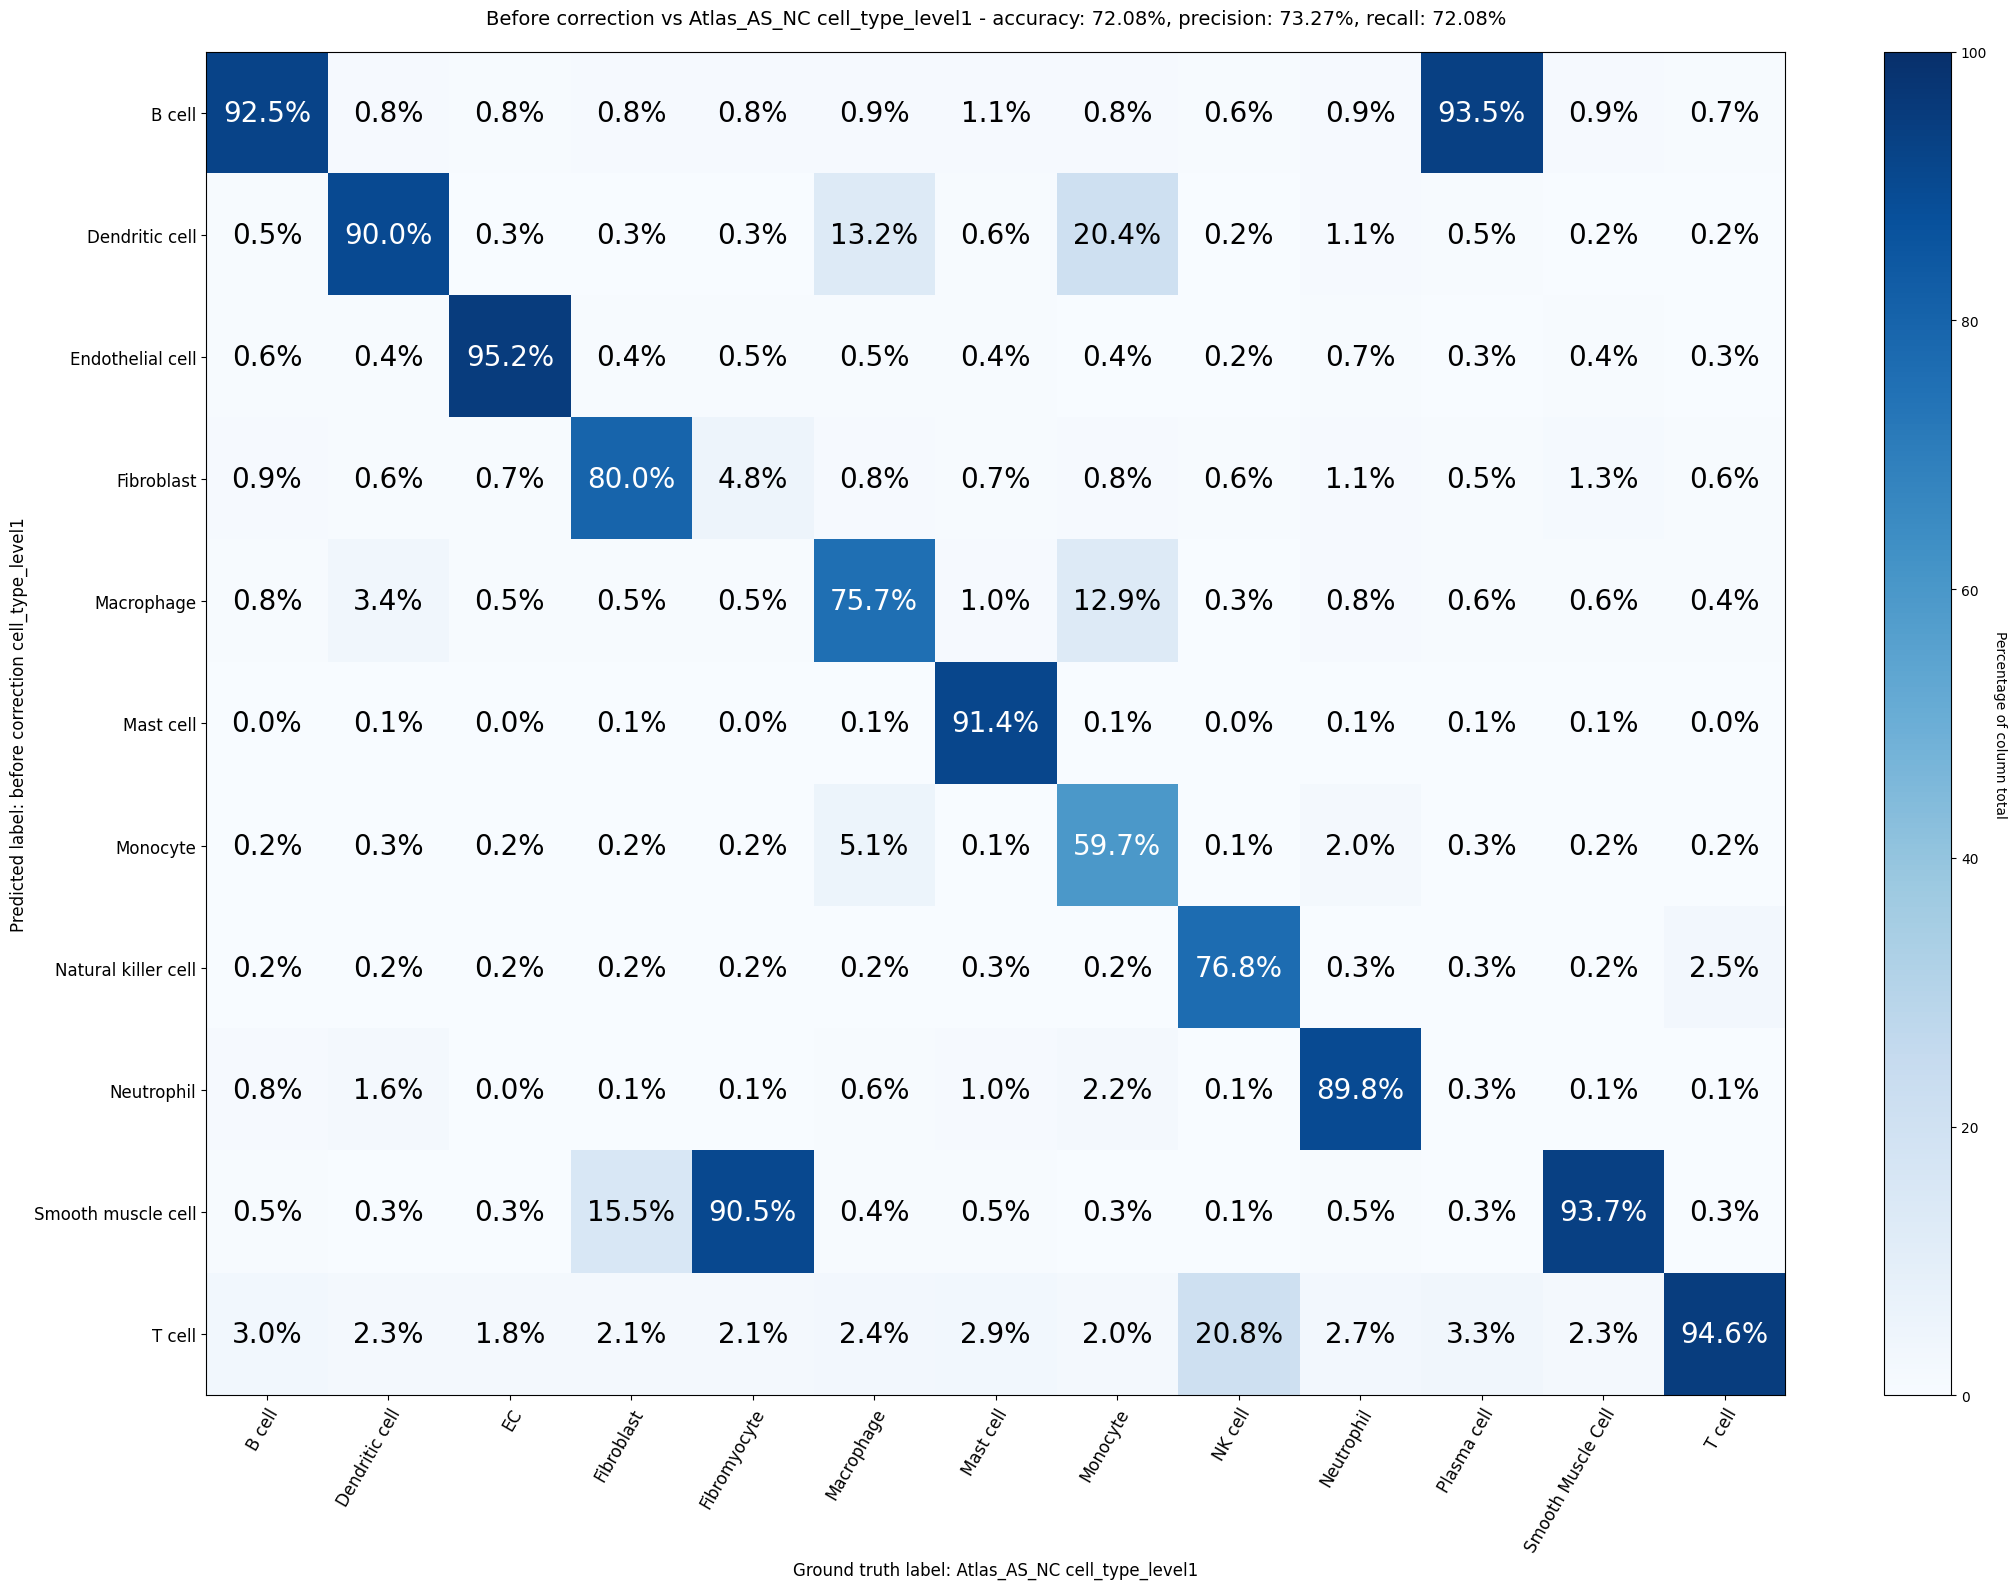


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.719773
1        Dendritic cell   0.457645
2      Endothelial cell   0.000000
3            Fibroblast   0.792847
4            Macrophage   0.912183
5             Mast cell   0.950701
6              Monocyte   0.746818
7   Natural killer cell   0.000000
8            Neutrophil   0.817583
9    Smooth muscle cell   0.000000
10               T cell   0.956545

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.925149
1       Dendritic cell  0.899792
2                   EC  0.000000
3           Fibroblast  0.799594
4         Fibromyocyte  0.000000
5           Macrophage  0.757049
6            Mast cell  0.913913
7             Monocyte  0.597388
8              NK cell  0.000000
9           Neutrophil  0.897636
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.946026


In [7]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1_corrected"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1_corrected"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_corrected"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

当前 AnnData 中共有 548208 个细胞
去除指定细胞类型后共有 531954 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 203513 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.6531
Weighted precision: 0.7379
Weighted recall: 0.6531

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


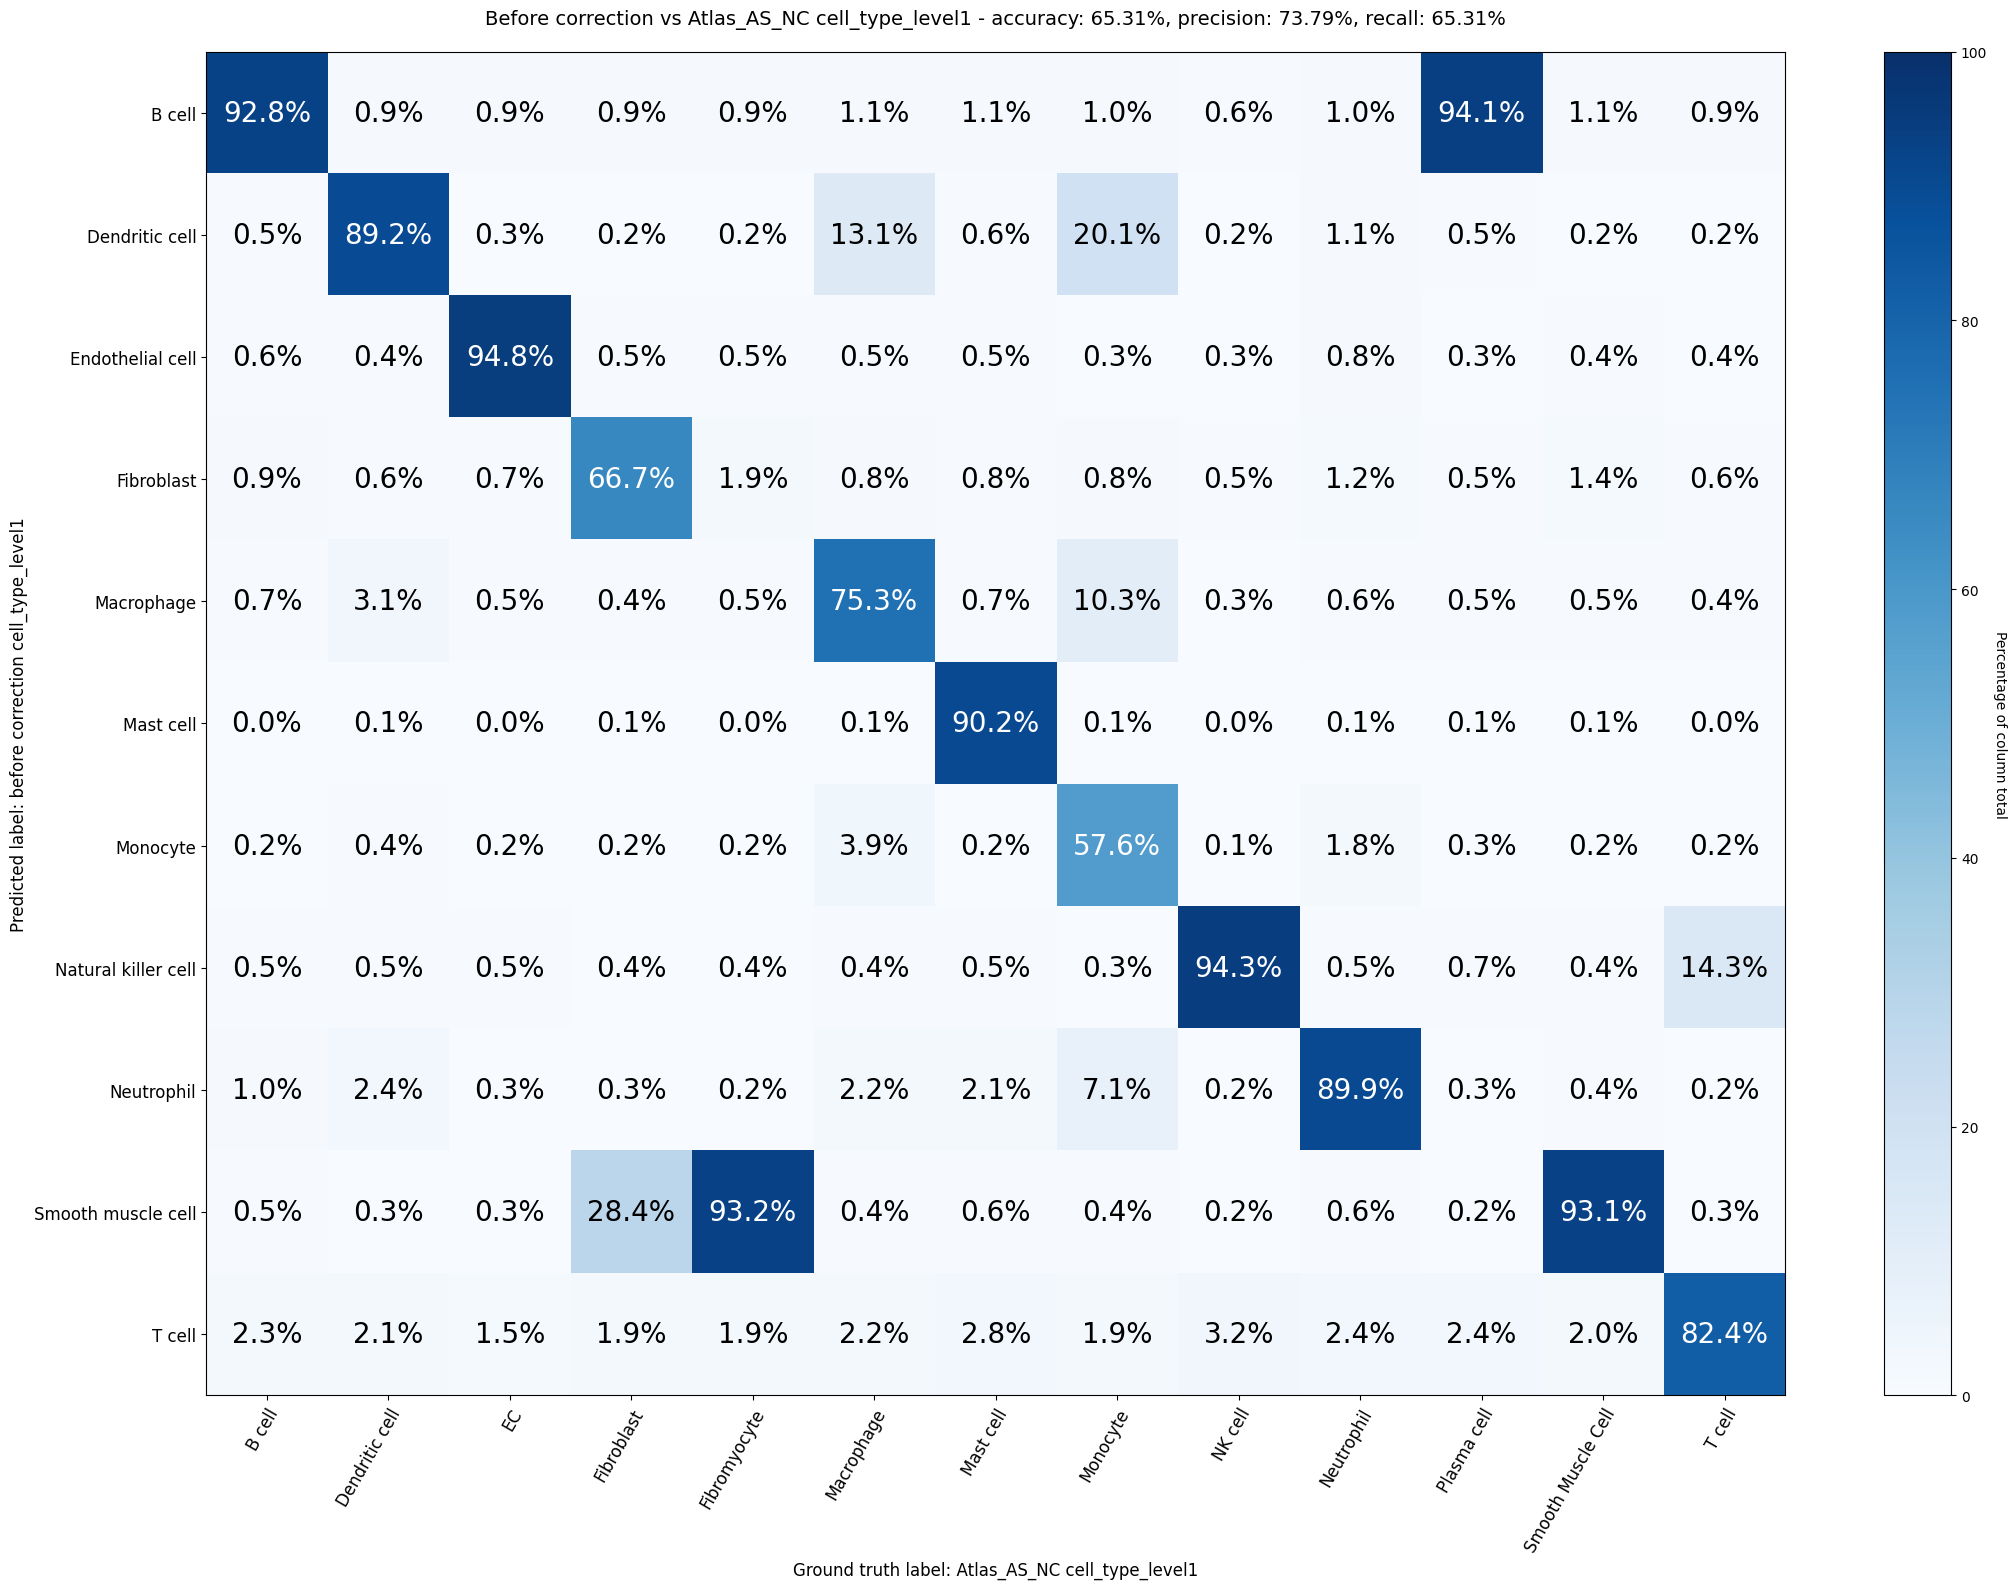


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.690076
1        Dendritic cell   0.457645
2      Endothelial cell   0.000000
3            Fibroblast   0.784897
4            Macrophage   0.923809
5             Mast cell   0.950701
6              Monocyte   0.780006
7   Natural killer cell   0.000000
8            Neutrophil   0.625361
9    Smooth muscle cell   0.000000
10               T cell   0.973094

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.927947
1       Dendritic cell  0.892045
2                   EC  0.000000
3           Fibroblast  0.667290
4         Fibromyocyte  0.000000
5           Macrophage  0.753087
6            Mast cell  0.901759
7             Monocyte  0.576316
8              NK cell  0.000000
9           Neutrophil  0.899281
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.823969


In [24]:
###校正前
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)